In [1]:
! pip install scanpy pandas numpy squidpy cell2location matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 7.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is s

In [2]:
# -- Imports
import os
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import cell2location
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel
import matplotlib.pyplot as plt
import matplotlib as mpl

/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [4]:
# -- Paths
input_path_sc = "/content/drive/MyDrive/endo-immune-atlas/data/processed/GSE179640_immunosenescence.h5ad"

input_path_GSM6690475_BEME_346 = "/content/drive/MyDrive/endo-immune-atlas/data/processed/GSM6690475_BEME_346.h5ad"


input_path_GSM6690476_BEME_355G = "/content/drive/MyDrive/endo-immune-atlas/data/processed/GSM6690476_BEME_355G.h5ad"

output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"
output_path_figures = "/content/drive/MyDrive/endo-immune-atlas/results/final_figures"

os.makedirs(output_path_figures, exist_ok=True)

In [5]:
# -- Import objects
immune_obj = sc.read_h5ad(input_path_sc)
adata_346 = sc.read_h5ad(input_path_GSM6690475_BEME_346)
adata_355G = sc.read_h5ad(input_path_GSM6690476_BEME_355G)

In [6]:
#===========================================================
# TISSUE #1: BEME_346
#===========================================================

# GET RID OF MT GENES - this is just a sanity check
adata_346.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_346.var['gene_ids']]

adata_346.obsm['MT'] = adata_346[:, adata_346.var['MT_gene'].values].X.toarray()
adata_346 = adata_346[:, ~adata_346.var['MT_gene'].values]

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


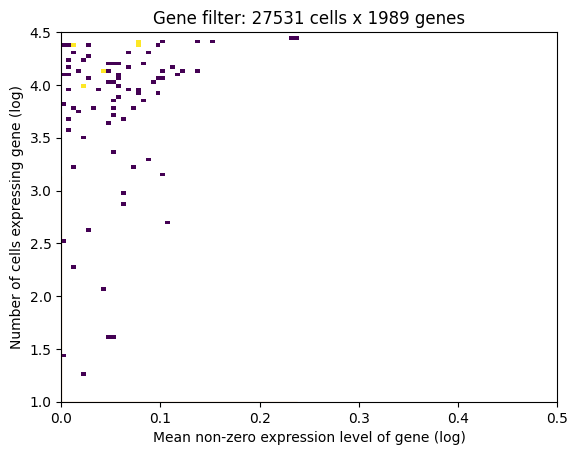

/tmp/ipykernel_862/3177939442.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  immune_ref.obs["immune_cell_type"] = immune_ref.obs["immune_cell_type"].replace({


In [7]:
# -- SELECT GENES
selected = filter_genes(immune_obj, cell_count_cutoff=5, cell_percentage_cutoff2=0.05, nonz_mean_cutoff=0.05)

# filter the object
immune_ref = immune_obj[:, selected].copy()


# -- MERGING DENDRITIC SUBTYPES
immune_ref.obs["immune_cell_type"] = immune_ref.obs["immune_cell_type"].replace({
    "cDC1": "Dendritic cells",
    "cDC2": "Dendritic cells",
    "pDC": "Dendritic cells"
})

In [8]:
# prepare anndata for the regression model

immune_ref.X = immune_ref.layers["counts"].copy()

cell2location.models.RegressionModel.setup_anndata(adata=immune_ref,
                        batch_key='sample_id',
                        # cell type, covariate used for constructing signatures
                        labels_key='immune_cell_type'
                       )

In [9]:
# -- CREATE REGRESSION MODEL
mod = RegressionModel(immune_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_id',
│   'labels_key': 'immune_cell_type',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  24   │
│         n_cells          │ 27531 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  11   │
│          n_vars          │ 1989  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                         batch State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_id'] │ GSM6102532_C01_Ctrl │          0          │
│                        │ GSM6102533_C02_Ctrl │          1          │
│                        │ GSM6102534_C03_Ctrl │          2          │
│                        │ GSM6102537_E01_EuE  │          3          │
│                        │ GSM6102540_E02_EuE  │          4          │
│                        │ GSM6102543_E03_EuE  │          5          │
│                        │ GSM6102546_E04_EuE  │          6          │
│                        │ GSM6102549_E05_EuE  │          7          │
│                        │ GSM6102550_E06_EcP  │          8          │
│                        │ GSM6102551_E06_EuE  │          9          │
│                        │ GSM6102552_E07_EcO  │         10          │
│                        │ GSM6102553_E07_EcP  │         11          │
│                        │ GSM6102554_E07_EuE  │         12          │
│                        │ GSM6102555_E08_EuE  │         13          │
│                        │ GSM6102556_E09_EcO  │         14          │
│                        │ GSM6102560_E09_EuE  │         15          │
│                        │ GSM6102562_E11_EcO  │         16          │
│                        │ GSM6595248_E01_EcP  │         17          │
│                        │ GSM6595250_E02_EcP  │         18          │
│                        │ GSM6595252_E03_EcP  │         19          │
│                        │ GSM6595254_E04_EcP  │         20          │
│                        │ GSM6595256_E05_EcP  │         21          │
│                        │ GSM6595258_E09_EcP  │         22          │
│                        │ GSM6595261_E10_EcO  │         23          │
└────────────────────────┴─────────────────────┴─────────────────────┘

                                labels State Registry                                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃        Source Location        ┃         Categories          ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['immune_cell_type'] │     Classical Monocytes     │          0          │
│                               │   Non-Classical Monocytes   │          1          │
│                               │ Tissue Resident Macrophages │          2          │
│                               │       Dendritic cells       │          3          │
│                               │       CD16+ NK cells        │          4          │
│                               │       CD16- NK cells        │          5          │
│                               │         CD4 T cells         │          6          │
│                               │         CD8 T cells         │          7          │
│                               │            Tregs            │          8          │
│                               │         γδ T cells          │          9          │
│                               │           B cells           │         10          │
└───────────────────────────────┴─────────────────────────────┴─────────────────────┘

In [10]:
# -- TRAIN THE MODEL
mod.train(max_epochs=250, accelerator='gpu')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: You are using a CUDA device ('NVIDIA RTX PRO 60

Training:   0%|          | 0/250 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=250` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=250` reached.


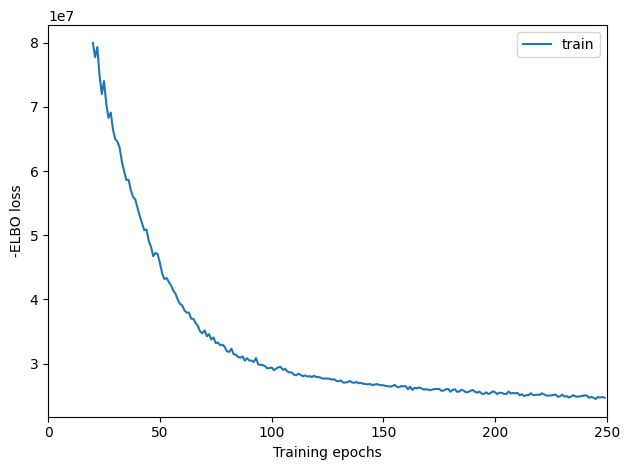

In [11]:
mod.plot_history(20)

In [12]:
# -- SAVE RESULTS
immune_ref = mod.export_posterior(
    immune_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500, 'accelerator': 'gpu'}
)

# Save model
mod.save(f"{output_path_data}/immune_reference_model", overwrite=True)

# Save anndata object with results
immune_ref.write_h5ad(
    f"{output_path_data}/immune_reference_posterior.h5ad")
immune_ref

Sampling local variables, batch:   0%|          | 0/12 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 27531 × 1989
    obs: 'sample_id', 'patient_id', 'tissue_type', 'condition', 'lesion_site', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'outlier_mt', 'doublet_score', 'predicted_doublet', 'leiden_res_0.01', 'leiden_res_0.02', 'leiden_res_0.05', 'cluster_label', 'leiden_res_0.20', 'leiden_res_0.50', 'leiden_res_1.00', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'immune_cell_type', 'lineage', 'core_sen_score', 'sasp_score', 'innate_sen_score', 'adaptive_sen_score', 'innate_composite_score', 'adaptive_composite_score', 'composite_sen_score', 'tcell_exhaustion_score', 'nk_dysfunction_score', 'macrophage_dysfunction_score', 'bcell_exhaustion_score', 'cdc1_dysfunction_score', 'cdc2_dysfunction_score', 'pdc_dysfunction_score', 'dysfunction_score', 'plot_sen_score', 'senescent_state', 'dysfunction_state', 'sen_dysfunction_label', '_indices', '_scvi_batch', '_scvi_labe

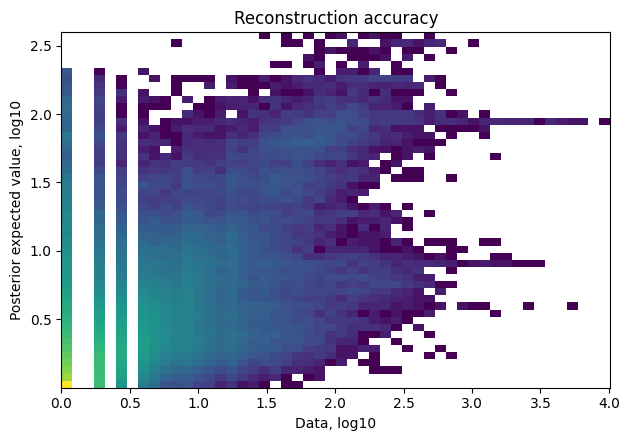

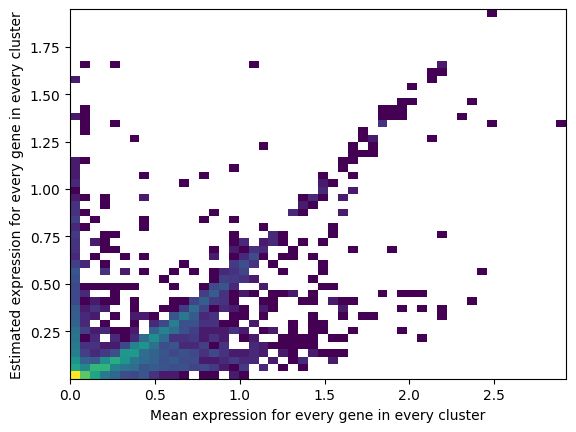

In [13]:
# -- CHECK QC
mod.plot_QC()

In [14]:
# -- EXPORT EST. EXPRESSION IN EACH CLUSTER
if 'means_per_cluster_mu_fg' in immune_ref.varm.keys():
    inf_aver = immune_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in immune_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = immune_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in immune_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = immune_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,Classical Monocytes,Non-Classical Monocytes,Tissue Resident Macrophages,Dendritic cells,CD16+ NK cells
A2M,0.004081,0.005920,0.635050,0.546714,0.009382
A2M-AS1,0.001137,0.014279,0.004635,0.008901,0.063176
ABCA6,0.001705,0.001439,0.051827,0.009149,0.000314
ABCA8,0.000218,0.000799,0.001602,0.001093,0.000332
ABCB1,0.000873,0.007846,0.015476,0.010399,0.053452


In [15]:
# -- SPATIAL MAPPING

# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_346.var_names, inf_aver.index)
adata_346 = adata_346[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_346)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [16]:
# -- CREATE THE SPATIAL MODEL
mod = cell2location.models.Cell2location(
    adata_346, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 1388  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 1966  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30000` reached.


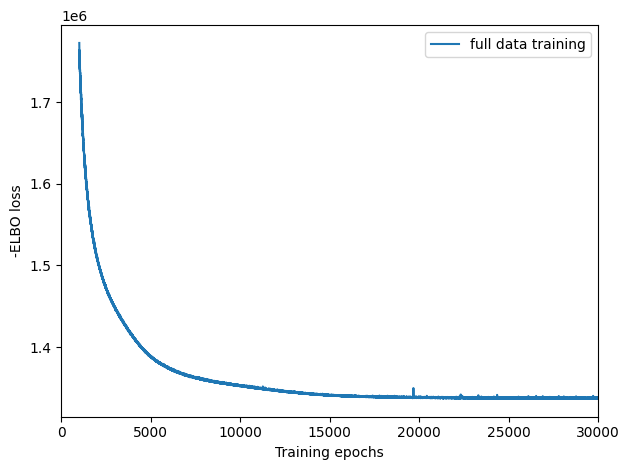

In [17]:
# -- TRAIN THE MODEL
mod.train(max_epochs=30000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1,
          accelerator='gpu',
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training']);

In [18]:
# -- SAVE RESULTS
adata_346 = mod.export_posterior(
    adata_346, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'accelerator': 'gpu'}
)

# Save model
mod.save(f"{output_path_data}/adata_346_model", overwrite=True)

# Save anndata object with results

adata_346.write_h5ad(
    f"{output_path_data}/adata_346_posterior.h5ad")
adata_346

Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1388 × 1966
    obs: 'in_tissue', 'array_row', 'array_col', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'MT_gene'
    uns: 'spatial', '_scvi_uuid', '_scvi_manager_uuid', 'mod'
    obsm: 'spatial', 'MT', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'

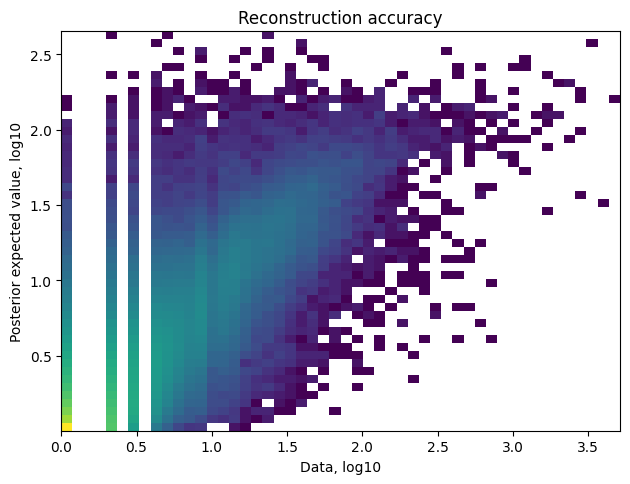

In [19]:
# -- CHECK QC

mod.plot_QC()

In [20]:
# ADD Cell2location EST. ABUNDANCES TO OBS
adata_346.obs = adata_346.obs.join(
    adata_346.obsm["means_cell_abundance_w_sf"]
)

In [21]:
adata_346.obs.rename(
    columns=lambda x: x.replace("meanscell_abundance_w_sf_", ""),
    inplace=True,
)

In [24]:
# -- PLOT IN SPATIAL COORDINATES
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):

    sc.pl.spatial(adata_346, cmap='magma',
                  color=["Classical Monocytes",
                         "Non-Classical Monocytes",
                         "Tissue Resident Macrophages",
                         "Dendritic cells",
                         "CD16+ NK cells",
                         "CD16- NK cells",
                         "CD4 T cells",
                         "CD8 T cells",
                         "Tregs",
                         "γδ T cells",
                         "B cells"],
                  ncols=4, size=1.3,
                  img_key='hires',
                  vmax="p99.2",
                  show=False
                 )

plt.savefig(
    os.path.join(output_path_figures, "07_adata_346_immune_cells_spatial_loc.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

/tmp/ipykernel_862/1827020758.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_346, cmap='magma',


In [25]:
# -- TOTAL CELL ABUNDANCE
immune_cols = [
    c for c in adata_346.obsm["means_cell_abundance_w_sf"].columns
]

adata_346.obs["Total immune"] = (
    adata_346.obsm["means_cell_abundance_w_sf"][immune_cols]
    .sum(axis=1)
)

sc.pl.spatial(
    adata_346,
    color="Total immune",
    cmap="magma",
    img_key="hires",
    vmax="p99.2",
    show=False
)

plt.savefig(
    os.path.join(output_path_figures, "07_adata_346_total_immune_cells_spatial_loc.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

/tmp/ipykernel_862/3857405660.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [26]:
# -- SAVE DATA

adata_346.write_h5ad(
    os.path.join(output_path_data, "BEME346_cell2location.h5ad")
)

In [27]:
#===========================================================
# TISSUE #2: BEME_355G
#===========================================================

# GET RID OF MT GENES - this is just a sanity checkadata_346.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_346.var['gene_ids']]

adata_346.obsm['MT'] = adata_346[:, adata_346.var['MT_gene'].values].X.toarray()
adata_346 = adata_346[:, ~adata_346.var['MT_gene'].values]

In [28]:
# -- SPATIAL MAPPING

# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_355G.var_names, inf_aver.index)
adata_355G = adata_355G[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_355G)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [29]:
# -- CREATE THE SPATIAL MODEL
mod = cell2location.models.Cell2location(
    adata_355G, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 1960  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 1966  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30000` reached.


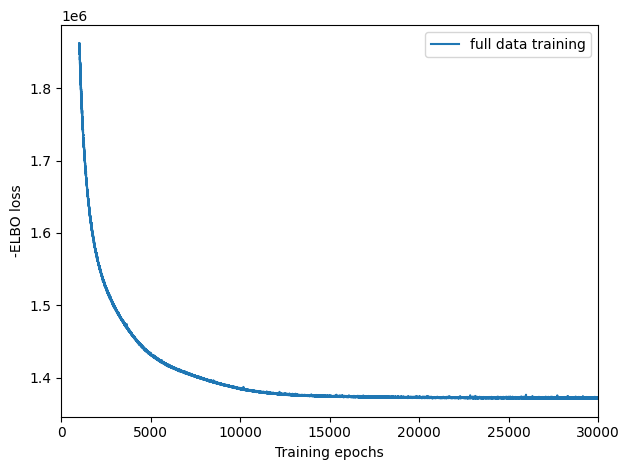

In [30]:
# -- TRAIN THE MODEL
mod.train(max_epochs=30000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1,
          accelerator='gpu',
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training']);

In [31]:
# -- SAVE RESULTS
adata_355G = mod.export_posterior(
    adata_355G, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'accelerator': 'gpu'}
)

# Save model
mod.save(f"{output_path_data}/adata_355G_model", overwrite=True)

# Save anndata object with results

adata_355G.write_h5ad(
    f"{output_path_data}/adata_355G_posterior.h5ad")
adata_355G

Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1960 × 1966
    obs: 'in_tissue', 'array_row', 'array_col', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial', '_scvi_uuid', '_scvi_manager_uuid', 'mod'
    obsm: 'spatial', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'

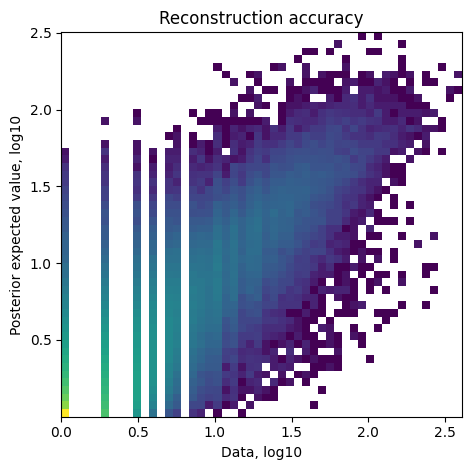

In [32]:
# -- CHECK QC

mod.plot_QC()

In [33]:
# ADD Cell2location EST. ABUNDANCES TO OBS
adata_355G.obs = adata_355G.obs.join(
    adata_355G.obsm["means_cell_abundance_w_sf"]
)

adata_355G.obs.rename(
    columns=lambda x: x.replace("meanscell_abundance_w_sf_", ""),
    inplace=True,
)

In [36]:
# -- PLOT IN SPATIAL COORDINATES
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):

    sc.pl.spatial(adata_355G, cmap='magma',
                  color=["Classical Monocytes",
                         "Non-Classical Monocytes",
                         "Tissue Resident Macrophages",
                         "Dendritic cells",
                         "CD16+ NK cells",
                         "CD16- NK cells",
                         "CD4 T cells",
                         "CD8 T cells",
                         "Tregs",
                         "γδ T cells",
                         "B cells"],
                  ncols=4, size=1.3,
                  img_key='hires',
                  vmax="p99.2",
                  show=False
                 )

plt.savefig(
    os.path.join(output_path_figures, "07_adata_355G_immune_cells_spatial_loc.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

/tmp/ipykernel_862/601933536.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_355G, cmap='magma',


In [37]:
# -- TOTAL CELL ABUNDANCE
immune_cols = [
    c for c in adata_355G.obsm["means_cell_abundance_w_sf"].columns
]

adata_355G.obs["Total immune"] = (
    adata_355G.obsm["means_cell_abundance_w_sf"][immune_cols]
    .sum(axis=1)
)

sc.pl.spatial(
    adata_355G,
    color="Total immune",
    cmap="magma",
    img_key="hires",
    vmax="p99.2",
    show=False
)

plt.savefig(
    os.path.join(output_path_figures, "07_adata_355G_total_immune_cells_spatial_loc.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

/tmp/ipykernel_862/3431628686.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [38]:
# -- SAVE DATA

adata_355G.write_h5ad(
    os.path.join(output_path_data, "BEME355G_cell2location.h5ad")
)

## Notebook Summary

Completed:
- Loaded trained immune reference
- Mapped immune populations onto Visium tissue
- Estimated cell abundance per spot
- Visualized spatial distribution
- Saved annotated spatial objects

Notes:
- Cell2location could not discriminate the difference between DC subpopulations so they will be merged into 1 central group "DCs" for downstream analysis.

Next notebook:
08_spatial_neighborhood_analysis.ipynb